# 09 · Descriptivos de los subcomponentes del COM-B

Equivalente al notebook `11_descriptivos_diccionarios_literatura.ipynb` de Karen,
adaptado al marco COM-B: analiza la distribución y evolución de los
**6 subcomponentes** (Capacidad física/psicológica, Oportunidad física/social,
Motivación reflexiva/automática) detectados en el corpus, más la agregación
a los 3 componentes mayores (C, O, M).

**Entrada:** `comb_tweets_final.parquet`, `corpus_cleaned.parquet`
**Salida:** `descriptivos_subcategorias_comb.xlsx`, `distribucion_componentes_COM.xlsx`, figuras


In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosCOMB')

# Columnas de subcomponentes COM-B (scores del clasificador)
COLS_SUBCATS = [
    'COMB_Capacidad_fisica',
    'COMB_Capacidad_psicologica',
    'COMB_Motivacion_automatica',
    'COMB_Motivacion_reflexiva',
    'COMB_Oportunidad_fisica',
    'COMB_Oportunidad_social',
]

# Etiquetas cortas para graficos
LABELS_CORTOS = {
    'COMB_Capacidad_fisica'      : 'Capacidad física',
    'COMB_Capacidad_psicologica' : 'Capacidad psicológica',
    'COMB_Motivacion_automatica' : 'Motivación automática',
    'COMB_Motivacion_reflexiva'  : 'Motivación reflexiva',
    'COMB_Oportunidad_fisica'    : 'Oportunidad física',
    'COMB_Oportunidad_social'    : 'Oportunidad social',
}

# Componente mayor (C / O / M) para agregaciones
COMPONENTE_MAYOR = {
    'COMB_Capacidad_fisica'      : 'Capacidad',
    'COMB_Capacidad_psicologica' : 'Capacidad',
    'COMB_Motivacion_automatica' : 'Motivación',
    'COMB_Motivacion_reflexiva'  : 'Motivación',
    'COMB_Oportunidad_fisica'    : 'Oportunidad',
    'COMB_Oportunidad_social'    : 'Oportunidad',
}

print('[CONFIG] OK')


[CONFIG] OK


In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Subcorpus del COM-B — merge incluye Fecha
df = pd.read_parquet(DATA_PROCESSED / 'comb_tweets_final.parquet')
df = df.merge(
    corpus[['id_doc', 'Author_Normalized', 'Entidad', 'Fecha', 'Texto_limpio']],
    on='id_doc', how='left'
)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df['Anio']  = df['Fecha'].dt.year

print(f'Corpus completo     : {len(corpus):,} tweets')
print(f'Subcorpus comp.     : {len(df):,} tweets')
print(f'Subcategorias       : {len(COLS_SUBCATS)}')
df.head(2)


Corpus completo     : 151,424 tweets
Subcorpus comp.     : 12,254 tweets
Subcategorias       : 6


,chunk_id,id_doc,texto_chunk,COMB_Capacidad_fisica,COMB_Capacidad_psicologica,COMB_Motivacion_automatica,COMB_Motivacion_reflexiva,COMB_Oportunidad_fisica,COMB_Oportunidad_social,score_max,subcat_max,etiqueta_comb,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio,Anio
0,5_1,5,Local Gestionan regidores cajas para intubació...,0.374892,0.315076,0.261424,0.284109,0.510342,0.272318,0.510342,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,@cscnoticias1,"Noticias locales, nacionales o globales",2020-06-03,Local Gestionan regidores cajas para intubació...,2020
1,6_1,6,La otra semana ya saldrá el aumento de contagi...,0.281226,0.367581,0.299257,0.363866,0.482989,0.208974,0.482989,COMB_Oportunidad_fisica,1,COMB_Oportunidad_fisica,@bebita11385037,Autoridad local de salud o gobierno,2020-06-03,La otra semana ya saldrá el aumento de contagi...,2020


In [3]:
# ============================================================
# CELL 2 — DISTRIBUCIÓN GENERAL DE SUBCATEGORÍAS
# ============================================================

# Frecuencia por subcategoría (subcat_max = subcategoría dominante por tweet)
freq_subcat = (
    df['subcat_max']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Subcategoria', 'subcat_max': 'Frecuencia'})
)
# compatibilidad pandas
freq_subcat.columns = ['Subcategoria', 'Frecuencia']
freq_subcat['Porcentaje'] = (freq_subcat['Frecuencia'] / len(df) * 100).round(2)
freq_subcat['Label'] = freq_subcat['Subcategoria'].map(LABELS_CORTOS).fillna(freq_subcat['Subcategoria'])

print(freq_subcat.to_string(index=False))


              Subcategoria  Frecuencia  Porcentaje                 Label
   COMB_Oportunidad_fisica        6009       49.04    Oportunidad física
 COMB_Motivacion_reflexiva        3031       24.73  Motivación reflexiva
COMB_Capacidad_psicologica        1696       13.84 Capacidad psicológica
COMB_Motivacion_automatica         822        6.71 Motivación automática
   COMB_Oportunidad_social         461        3.76    Oportunidad social
     COMB_Capacidad_fisica         235        1.92      Capacidad física


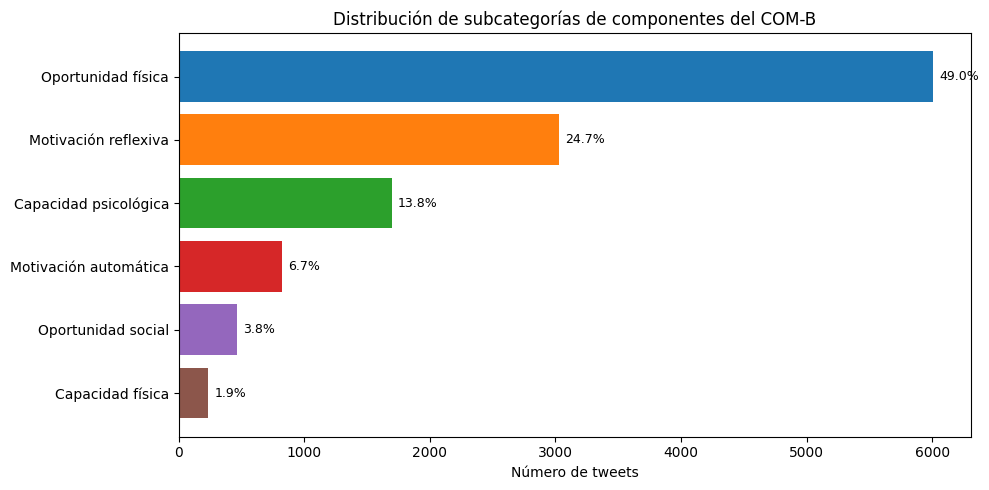

[GUARDADO] fig_distribucion_subcategorias_comp_detalle.png


In [4]:
# ============================================================
# CELL 3 — GRÁFICO BARRAS DISTRIBUCIÓN SUBCATEGORÍAS
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("tab10", len(freq_subcat))
bars = ax.barh(freq_subcat['Label'], freq_subcat['Frecuencia'], color=palette)

for bar, pct in zip(bars, freq_subcat['Porcentaje']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_title('Distribución de subcategorías de componentes del COM-B')
ax.set_xlabel('Número de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_distribucion_subcategorias_comp_detalle.png', dpi=300)
plt.show()
print('[GUARDADO] fig_distribucion_subcategorias_comp_detalle.png')


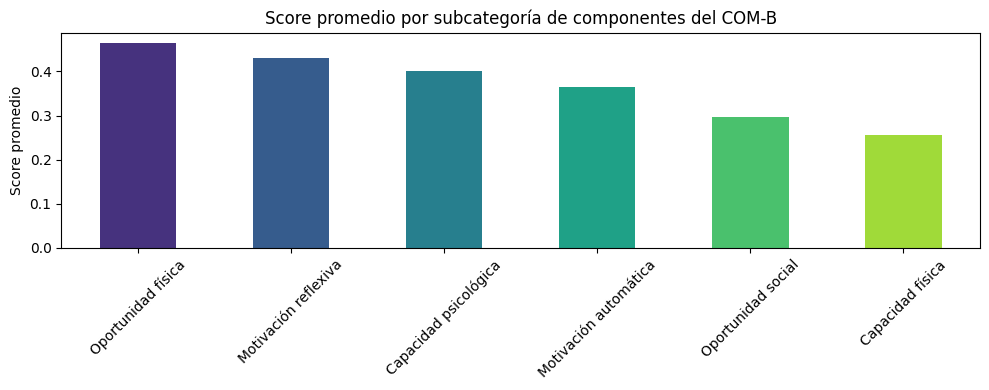

[GUARDADO] fig_scores_promedio_subcat_comp.png


In [5]:
# ============================================================
# CELL 4 — SCORES PROMEDIO POR SUBCATEGORÍA
# (muestra intensidad del clasificador, no solo el dominante)
# ============================================================
scores_prom = df[COLS_SUBCATS].mean().rename(LABELS_CORTOS)
scores_prom = scores_prom.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
scores_prom.plot(kind='bar', ax=ax, color=sns.color_palette("viridis", len(scores_prom)))
ax.set_title('Score promedio por subcategoría de componentes del COM-B')
ax.set_ylabel('Score promedio')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_scores_promedio_subcat_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_scores_promedio_subcat_comp.png')


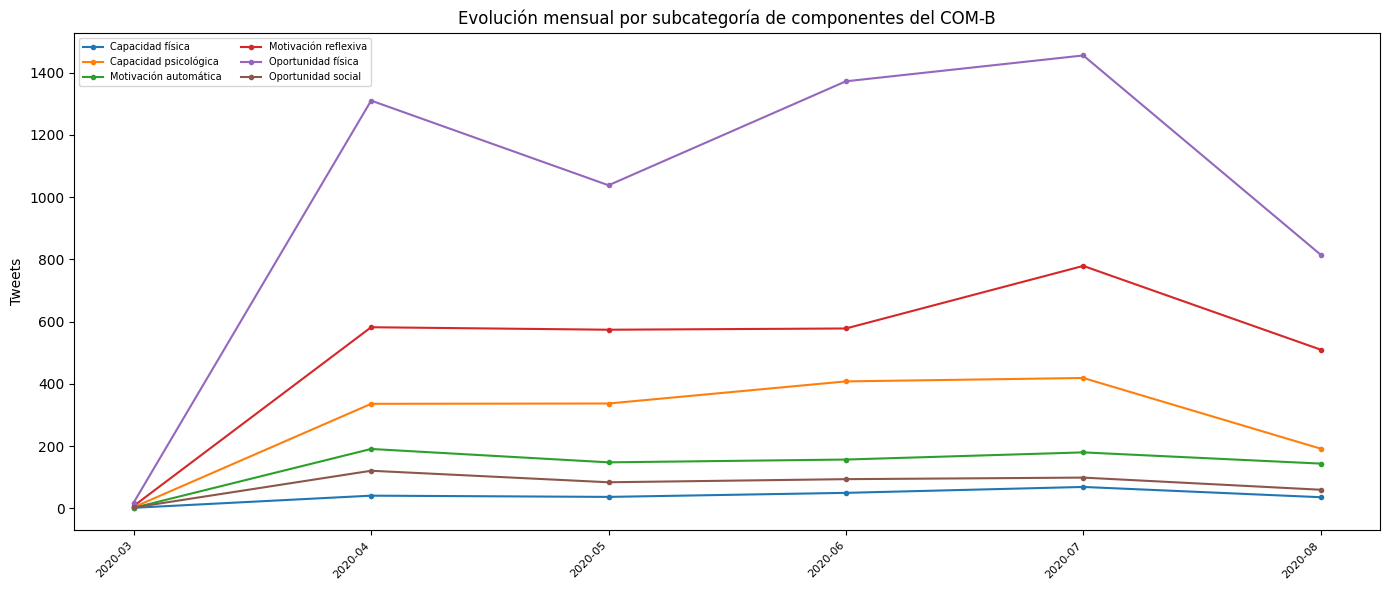

[GUARDADO] fig_evolucion_subcategorias_comp.png


In [6]:
# ============================================================
# CELL 5 — EVOLUCIÓN TEMPORAL POR SUBCATEGORÍA
# ============================================================
df['anio_mes'] = df['Fecha'].dt.to_period('M').astype(str)

evol = (
    df.groupby(['anio_mes', 'subcat_max'])
    .size()
    .reset_index(name='n')
)

# Pivot para tener una columna por subcategoría
evol_pivot = evol.pivot(index='anio_mes', columns='subcat_max', values='n').fillna(0)
evol_pivot.columns = [LABELS_CORTOS.get(c, c) for c in evol_pivot.columns]
evol_pivot = evol_pivot.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
for col in evol_pivot.columns:
    ax.plot(evol_pivot.index, evol_pivot[col], marker='o', markersize=3, label=col)

ax.set_title('Evolución mensual por subcategoría de componentes del COM-B')
ax.set_ylabel('Tweets')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=7, ncol=2)
step = max(1, len(evol_pivot) // 12)
ax.set_xticks(range(0, len(evol_pivot), step))
ax.set_xticklabels(evol_pivot.index[::step], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_subcategorias_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_subcategorias_comp.png')


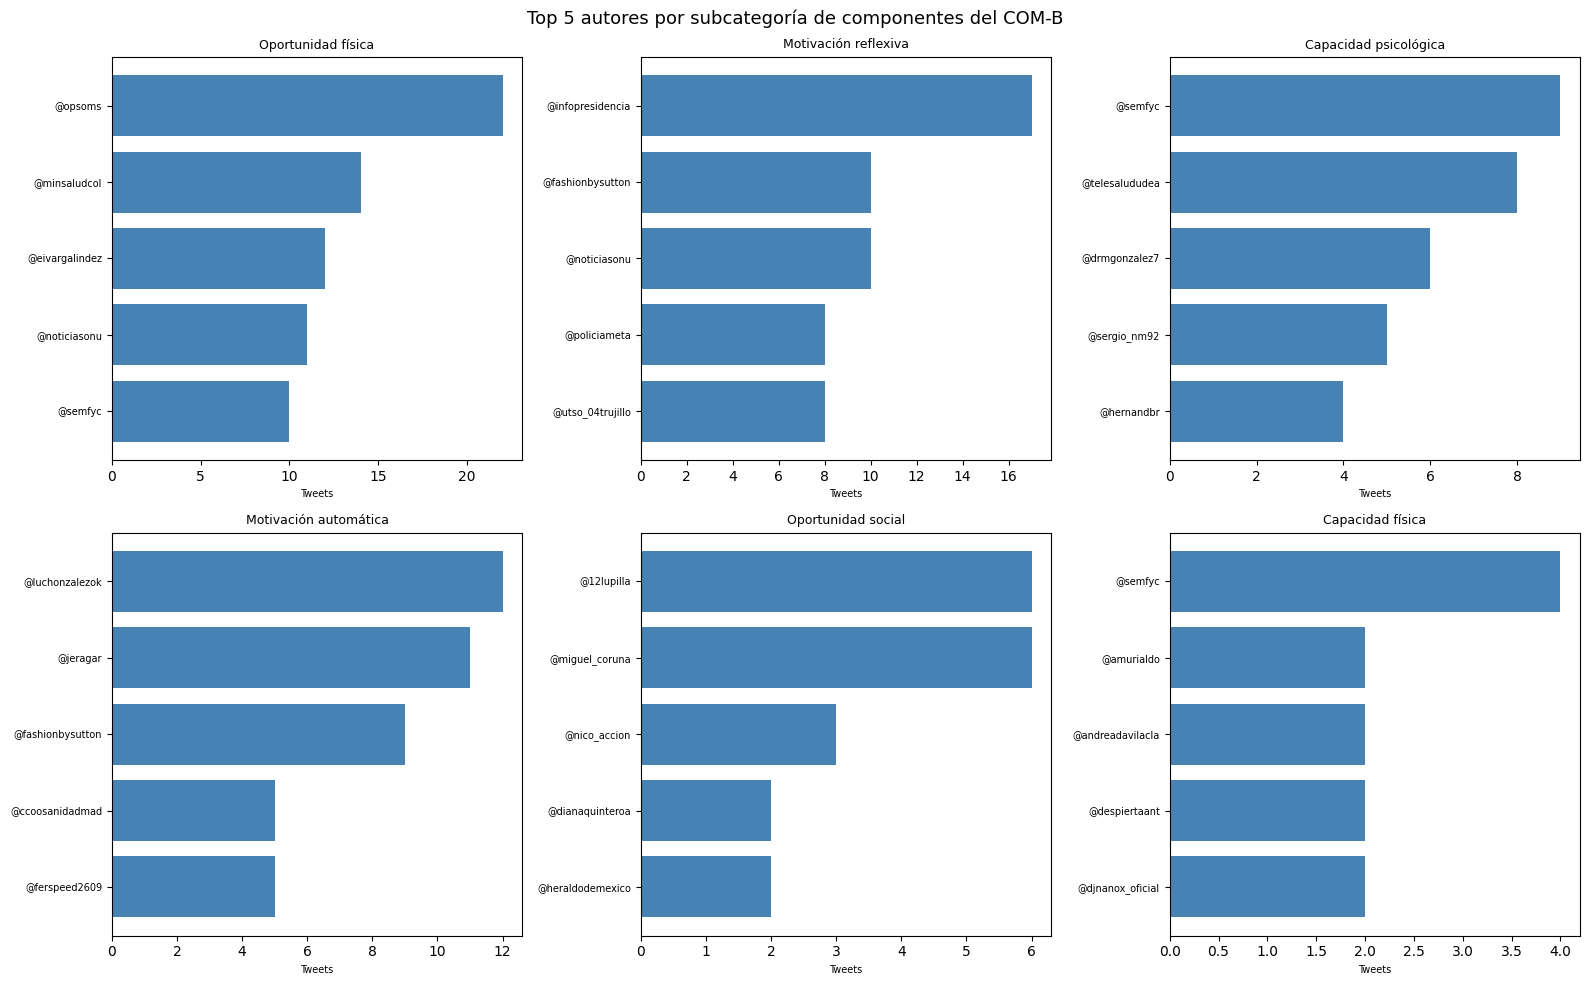

[GUARDADO] fig_autores_por_subcat_comp.png


In [7]:
# ============================================================
# CELL 6 — AUTORES MÁS ACTIVOS POR SUBCATEGORÍA
# ============================================================
top_autores_subcat = (
    df.groupby(['subcat_max', 'Author_Normalized'])
    .size()
    .reset_index(name='n')
    .sort_values(['subcat_max', 'n'], ascending=[True, False])
)
top5_por_subcat = top_autores_subcat.groupby('subcat_max').head(5)
top5_por_subcat['Label'] = top5_por_subcat['subcat_max'].map(LABELS_CORTOS).fillna(top5_por_subcat['subcat_max'])

subcats_orden = freq_subcat['Subcategoria'].tolist()
n_subcats = len(subcats_orden)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, subcat in enumerate(subcats_orden):
    ax = axes[i]
    subset = top5_por_subcat[top5_por_subcat['subcat_max'] == subcat].head(5)
    if subset.empty:
        ax.set_visible(False)
        continue
    ax.barh(subset['Author_Normalized'], subset['n'], color='steelblue')
    ax.set_title(LABELS_CORTOS.get(subcat, subcat), fontsize=9)
    ax.set_xlabel('Tweets', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

for j in range(n_subcats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 5 autores por subcategoría de componentes del COM-B', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_por_subcat_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_autores_por_subcat_comp.png')


In [8]:
# ============================================================
# CELL 7 — NORMALIZACIÓN (sin tildes) Y VERIFICACIÓN
# (Replica de Karen: normalizar texto para comparaciones)
# ============================================================
import unicodedata

def normalizar(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    return texto

# Verificar solapamiento entre subcategorías con scores altos
umbral = 0.5
solapamiento = {}
for i, col_a in enumerate(COLS_SUBCATS):
    for col_b in COLS_SUBCATS[i+1:]:
        n = ((df[col_a] >= umbral) & (df[col_b] >= umbral)).sum()
        if n > 0:
            solapamiento[f"{LABELS_CORTOS[col_a]} ∩ {LABELS_CORTOS[col_b]}"] = n

if solapamiento:
    df_sol = pd.DataFrame(list(solapamiento.items()), columns=['Par', 'N_tweets'])
    df_sol = df_sol.sort_values('N_tweets', ascending=False)
    print(f'Pares con solapamiento (score >= {umbral}):')
    print(df_sol.to_string(index=False))
else:
    print('Sin solapamientos significativos a umbral', umbral)


Pares con solapamiento (score >= 0.5):
                                          Par  N_tweets
    Motivación reflexiva ∩ Oportunidad física      1020
   Capacidad psicológica ∩ Oportunidad física       428
 Capacidad psicológica ∩ Motivación reflexiva       314
 Motivación automática ∩ Motivación reflexiva       208
   Motivación automática ∩ Oportunidad física        97
Capacidad psicológica ∩ Motivación automática        40
   Motivación automática ∩ Oportunidad social        21
   Capacidad psicológica ∩ Oportunidad social        15
      Oportunidad física ∩ Oportunidad social        15
    Motivación reflexiva ∩ Oportunidad social        11
     Capacidad física ∩ Motivación automática         9
        Capacidad física ∩ Oportunidad social         2
        Capacidad física ∩ Oportunidad física         1
      Capacidad física ∩ Motivación reflexiva         1


In [9]:
# ============================================================
# CELL 8 — GUARDAR TABLAS
# ============================================================
ruta_excel = DATA_PROCESSED / 'descriptivos_subcategorias_comb.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_subcat.to_excel(writer, sheet_name='Frecuencia_subcat', index=False)
    scores_prom.reset_index().rename(columns={'index': 'Subcategoria', 0: 'Score_promedio'}).to_excel(
        writer, sheet_name='Scores_promedio', index=False
    )
    evol_pivot.reset_index().to_excel(writer, sheet_name='Evolucion_mensual', index=False)
    top5_por_subcat.to_excel(writer, sheet_name='Top5_autores_subcat', index=False)

print('[GUARDADO] descriptivos_subcategorias_comb.xlsx')
print()
print('Notebook 09 completado.')
print('Siguiente -> 10_busqueda_lugares_instituciones.ipynb')


[GUARDADO] descriptivos_subcategorias_comb.xlsx

Notebook 09 completado.
Siguiente -> 10_busqueda_lugares_instituciones.ipynb


## Extra · Agregación a los componentes mayores (C, O, M)

 Componente  Frecuencia  Porcentaje
Oportunidad        6470       52.80
 Motivación        3853       31.44
  Capacidad        1931       15.76


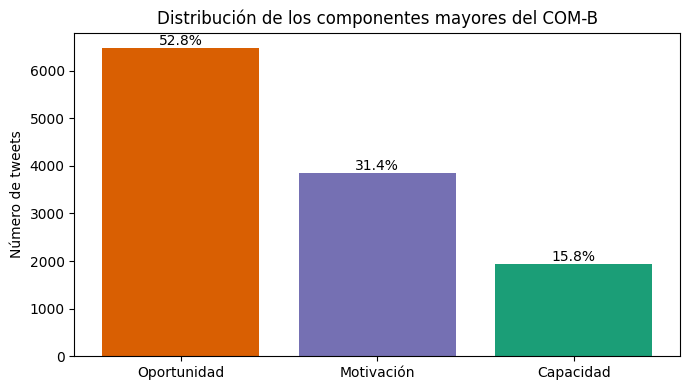

[GUARDADO] fig_componentes_mayores_COM.png


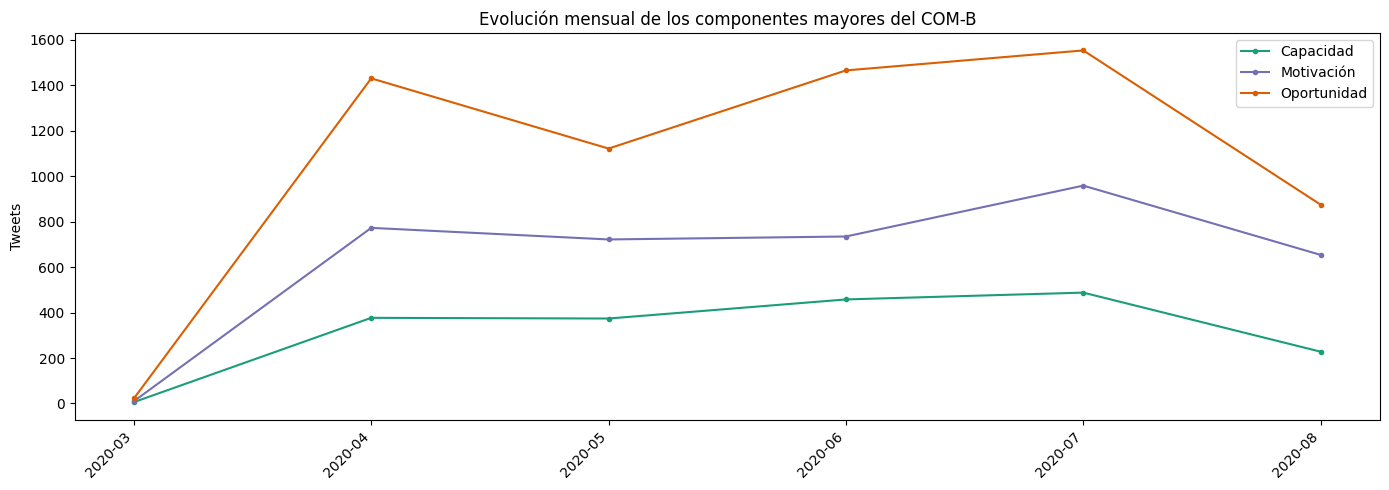

[GUARDADO] fig_evolucion_componentes_COM.png
[GUARDADO] distribucion_componentes_COM.xlsx


In [10]:
# ============================================================
# CELL EXTRA — AGREGACION A LOS 3 COMPONENTES MAYORES (C, O, M)
# Propio del COM-B: colapsa los 6 subcomponentes en Capacidad,
# Oportunidad y Motivacion.
# ============================================================

df['componente_mayor'] = df['subcat_max'].map(COMPONENTE_MAYOR)

freq_com = (
    df['componente_mayor'].value_counts()
    .reset_index()
)
freq_com.columns = ['Componente', 'Frecuencia']
freq_com['Porcentaje'] = (freq_com['Frecuencia'] / len(df) * 100).round(2)
print(freq_com.to_string(index=False))

# Barras C / O / M
fig, ax = plt.subplots(figsize=(7, 4))
colores = {'Capacidad': '#1b9e77', 'Oportunidad': '#d95f02', 'Motivación': '#7570b3'}
ax.bar(freq_com['Componente'], freq_com['Frecuencia'],
       color=[colores.get(c, 'gray') for c in freq_com['Componente']])
for i, (v, p) in enumerate(zip(freq_com['Frecuencia'], freq_com['Porcentaje'])):
    ax.text(i, v, f'{p:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribución de los componentes mayores del COM-B')
ax.set_ylabel('Número de tweets')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_componentes_mayores_COM.png', dpi=300)
plt.show()
print('[GUARDADO] fig_componentes_mayores_COM.png')

# Evolucion mensual C / O / M
evol_com = (
    df.groupby(['anio_mes', 'componente_mayor']).size()
    .reset_index(name='n')
    .pivot(index='anio_mes', columns='componente_mayor', values='n')
    .fillna(0).sort_index()
)
fig, ax = plt.subplots(figsize=(14, 5))
for col in evol_com.columns:
    ax.plot(evol_com.index, evol_com[col], marker='o', markersize=3,
            label=col, color=colores.get(col, None))
ax.set_title('Evolución mensual de los componentes mayores del COM-B')
ax.set_ylabel('Tweets')
ax.legend()
step = max(1, len(evol_com) // 12)
ax.set_xticks(range(0, len(evol_com), step))
ax.set_xticklabels(evol_com.index[::step], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_componentes_COM.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_componentes_COM.png')

# Guardar tabla
freq_com.to_excel(DATA_PROCESSED / 'distribucion_componentes_COM.xlsx',
                  index=False, engine='openpyxl')
print('[GUARDADO] distribucion_componentes_COM.xlsx')
